## 0. Подключение Google Drive (общая папка для всех 6 ноутбуков)
Запусти эту ячейку первой. Она монтирует Drive и переключает рабочую папку в `/content/drive/MyDrive/happiness_formula`, чтобы все ноутбуки видели файлы друг друга через `artifacts/`, даже если ты запускаешь их в разных сессиях.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path

PROJECT_PATH = '/content/drive/MyDrive/happiness_formula'  # можешь поменять имя папки
os.makedirs(PROJECT_PATH, exist_ok=True)
os.chdir(PROJECT_PATH)

print('Текущая рабочая папка:', os.getcwd())

data_json = Path(PROJECT_PATH) / 'data.json'
if data_json.exists():
    print('data.json найден')
else:
    print('data.json НЕ найден — положи его в', PROJECT_PATH, '(нужен только для ноутбука 01)')

artifacts_dir = Path(PROJECT_PATH) / 'artifacts'
if artifacts_dir.exists():
    existing = sorted(p.name for p in artifacts_dir.iterdir())
    print(f'В artifacts/ уже есть {len(existing)} файлов/папок:')
    for name in existing:
        print(' -', name)
else:
    print('Папка artifacts/ пока пустая, появится после первого запуска')


Mounted at /content/drive
Текущая рабочая папка: /content/drive/MyDrive/happiness_formula
data.json найден
В artifacts/ уже есть 10 файлов/папок:
 - 01_eda.png
 - 01_sentiment_sample.csv
 - 01_vk_posts.csv
 - 01_vk_users.csv
 - 02_cm_logreg.png
 - 02_logreg_metrics.json
 - 02_logreg_model.joblib
 - 02_logreg_predictions.csv
 - 02_sentiment_split.joblib
 - 02_tfidf_vectorizer.joblib


# 03 — TF-IDF + LinearSVC + кросс-валидация

Раздел 6. Здесь обучается второй классический baseline и исправляется методологическая ошибка с cross-validation: `TfidfVectorizer` теперь находится внутри `Pipeline`, поэтому словарь строится отдельно на каждом train-fold и не видит validation-fold.

### Проверка зависимостей

In [2]:
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'sklearn': 'scikit-learn',
    'datasets': 'datasets',
    'joblib': 'joblib',
}

missing = [pkg for module, pkg in REQUIRED_PACKAGES.items() if importlib.util.find_spec(module) is None]
if missing:
    print('Устанавливаются отсутствующие зависимости:', ', '.join(missing))
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])
else:
    print('Все зависимости доступны.')

Все зависимости доступны.


## Импорты и конфигурация

In [3]:
import json
import os
import random
import re
import warnings
from pathlib import Path
from typing import Dict, Iterable, List, Tuple

warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

RANDOM_STATE = 42
PROJECT_DIR = Path.cwd()
ARTIFACT_DIR = PROJECT_DIR / 'artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_NAMES = ['Негативный', 'Позитивный', 'Нейтральный']
LABEL2NAME = {0: 'Негативный', 1: 'Позитивный', 2: 'Нейтральный'}
ID2LABEL = {0: 'NEGATIVE', 1: 'POSITIVE', 2: 'NEUTRAL'}
LABEL2ID = {'NEGATIVE': 0, 'POSITIVE': 1, 'NEUTRAL': 2}

TOXIC_KEYWORDS = [
    'депрессия', 'грусть', 'боль', 'слезы', 'слёзы', 'одиночество',
    'апатия', 'ненависть', 'суицид', 'смерть', 'безысходность',
]

sns.set_theme(style='whitegrid', palette='Set2')


def set_seed(seed: int = RANDOM_STATE) -> None:
    random.seed(seed)
    np.random.seed(seed)


set_seed(RANDOM_STATE)
print(f'Рабочая папка: {PROJECT_DIR}')
print(f'Папка артефактов: {ARTIFACT_DIR}')

import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

Рабочая папка: /content/drive/MyDrive/happiness_formula
Папка артефактов: /content/drive/MyDrive/happiness_formula/artifacts


In [4]:
def clean_text(text: str) -> str:
    """Очистка текста для TF-IDF и xLSTM. Для RuBERT используется исходный текст."""
    text = '' if pd.isna(text) else str(text)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^а-яёА-ЯЁa-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

## 6. TF-IDF + LinearSVC

In [5]:
split_path = ARTIFACT_DIR / '02_sentiment_split.joblib'
sentiment_path = ARTIFACT_DIR / '01_sentiment_sample.csv'

if split_path.exists():
    split = joblib.load(split_path)
else:
    if not sentiment_path.exists():
        raise FileNotFoundError('Не найдено ни разбиение 02_sentiment_split.joblib, ни 01_sentiment_sample.csv.')
    df_sample = pd.read_csv(sentiment_path)
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        df_sample['text'].astype(str).tolist(),
        df_sample['label'].astype(int).tolist(),
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=df_sample['label'].astype(int).tolist(),
    )
    split = {
        'X_train_raw': X_train_raw,
        'X_test_raw': X_test_raw,
        'X_train_clean': [clean_text(text) for text in X_train_raw],
        'X_test_clean': [clean_text(text) for text in X_test_raw],
        'y_train': y_train,
        'y_test': y_test,
    }
    joblib.dump(split, split_path)

X_train_raw = split['X_train_raw']
X_test_raw = split['X_test_raw']
X_train_clean = split['X_train_clean']
X_test_clean = split['X_test_clean']
y_train = split['y_train']
y_test = split['y_test']

print(f'Train: {len(X_train_raw)} | Test: {len(X_test_raw)}')

Train: 6000 | Test: 1500


TF-IDF + LinearSVC
              precision    recall  f1-score   support

  Негативный       0.50      0.50      0.50       500
  Позитивный       0.71      0.71      0.71       500
 Нейтральный       0.62      0.62      0.62       500

    accuracy                           0.61      1500
   macro avg       0.61      0.61      0.61      1500
weighted avg       0.61      0.61      0.61      1500



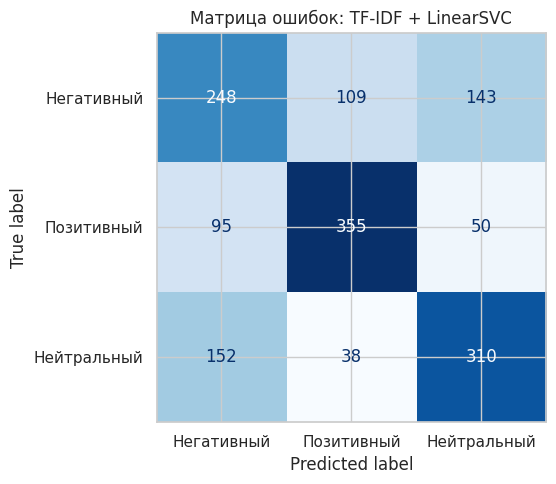

In [6]:
svc_vectorizer = TfidfVectorizer(
    max_features=20_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=3,
)
X_train_vec = svc_vectorizer.fit_transform(X_train_clean)
X_test_vec = svc_vectorizer.transform(X_test_clean)

svc = LinearSVC(max_iter=4000, C=0.5, random_state=RANDOM_STATE, class_weight='balanced')
svc.fit(X_train_vec, y_train)
svc_preds = svc.predict(X_test_vec)
svc_f1 = f1_score(y_test, svc_preds, average='weighted')
svc_accuracy = accuracy_score(y_test, svc_preds)

print('TF-IDF + LinearSVC')
print(classification_report(y_test, svc_preds, target_names=TARGET_NAMES))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, svc_preds)
ConfusionMatrixDisplay(cm, display_labels=TARGET_NAMES).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Матрица ошибок: TF-IDF + LinearSVC')
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / '03_cm_linearsvc.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.1 Кросс-валидация без утечки признаков

In [7]:
df_sample = pd.read_csv(sentiment_path)
X_all = df_sample['text'].astype(str)
y_all = df_sample['label'].astype(int)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

logreg_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20_000, ngram_range=(1, 2), sublinear_tf=True, min_df=3,
                              preprocessor=clean_text)),
    ('clf', LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE, class_weight='balanced')),
])

svc_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20_000, ngram_range=(1, 2), sublinear_tf=True, min_df=3,
                              preprocessor=clean_text)),
    ('clf', LinearSVC(max_iter=4000, C=0.5, random_state=RANDOM_STATE, class_weight='balanced')),
])

cv_logreg = cross_val_score(logreg_pipeline, X_all, y_all, cv=skf, scoring='f1_weighted', n_jobs=-1)
cv_svc = cross_val_score(svc_pipeline, X_all, y_all, cv=skf, scoring='f1_weighted', n_jobs=-1)

print('Результаты 5-кратной кросс-валидации без leakage, weighted F1:')
print(f'TF-IDF + LogReg:    {cv_logreg.mean():.4f} ± {cv_logreg.std():.4f}')
print(f'TF-IDF + LinearSVC: {cv_svc.mean():.4f} ± {cv_svc.std():.4f}')

Результаты 5-кратной кросс-валидации без leakage, weighted F1:
TF-IDF + LogReg:    0.6299 ± 0.0146
TF-IDF + LinearSVC: 0.6187 ± 0.0148


In [8]:
metrics = {
    'model': 'TF-IDF + LinearSVC',
    'type': 'Classical ML',
    'f1_weighted': float(svc_f1),
    'accuracy': float(svc_accuracy),
    'cv_logreg_f1_mean': float(cv_logreg.mean()),
    'cv_logreg_f1_std': float(cv_logreg.std()),
    'cv_svc_f1_mean': float(cv_svc.mean()),
    'cv_svc_f1_std': float(cv_svc.std()),
}

predictions_df = pd.DataFrame({
    'text': X_test_raw,
    'label_true': y_test,
    'label_pred': svc_preds,
})
predictions_df['label_true_name'] = predictions_df['label_true'].map(LABEL2NAME)
predictions_df['label_pred_name'] = predictions_df['label_pred'].map(LABEL2NAME)

joblib.dump(svc_vectorizer, ARTIFACT_DIR / '03_tfidf_vectorizer_svc.joblib')
joblib.dump(svc, ARTIFACT_DIR / '03_linearsvc_model.joblib')
with open(ARTIFACT_DIR / '03_linearsvc_metrics.json', 'w', encoding='utf-8') as file:
    json.dump(metrics, file, ensure_ascii=False, indent=2)
predictions_df.to_csv(ARTIFACT_DIR / '03_linearsvc_predictions.csv', index=False, encoding='utf-8-sig')

print('Метрики LinearSVC:')
print(json.dumps(metrics, ensure_ascii=False, indent=2))

Метрики LinearSVC:
{
  "model": "TF-IDF + LinearSVC",
  "type": "Classical ML",
  "f1_weighted": 0.6084069533176549,
  "accuracy": 0.6086666666666667,
  "cv_logreg_f1_mean": 0.6298969304384355,
  "cv_logreg_f1_std": 0.014606088811194703,
  "cv_svc_f1_mean": 0.6186617573032834,
  "cv_svc_f1_std": 0.014783439307040968
}
